# Data Cleaning

Data is come from kaggle, includes the historical data of S&P 500 index from 1927 to 2020 with columns of date, opening price, highest price, lowest price, closing price, adjusted closing price, and the number of shares traded each day.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SPX.csv")
print("Columns:", df.columns.tolist())
print(df.head())
print(df.info())

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
         Date       Open       High        Low      Close  Adj Close  Volume
0  1927-12-30  17.660000  17.660000  17.660000  17.660000  17.660000       0
1  1928-01-03  17.760000  17.760000  17.760000  17.760000  17.760000       0
2  1928-01-04  17.719999  17.719999  17.719999  17.719999  17.719999       0
3  1928-01-05  17.549999  17.549999  17.549999  17.549999  17.549999       0
4  1928-01-06  17.660000  17.660000  17.660000  17.660000  17.660000       0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23323 entries, 0 to 23322
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       23323 non-null  object 
 1   Open       23323 non-null  float64
 2   High       23323 non-null  float64
 3   Low        23323 non-null  float64
 4   Close      23323 non-null  float64
 5   Adj Close  23323 non-null  float64
 6   Volume     23323 non-null  int64

We noticed that volumes are all zerp, which is not normal. We want to check if all values of volume are 0.

In [3]:
print((df["Volume"] == 0).all())

False


not all zeros. Any regularities?

First non-zero index: 5496
Date         1950-01-03
Open              16.66
High              16.66
Low               16.66
Close             16.66
Adj Close         16.66
Volume          1260000
Name: 5496, dtype: object


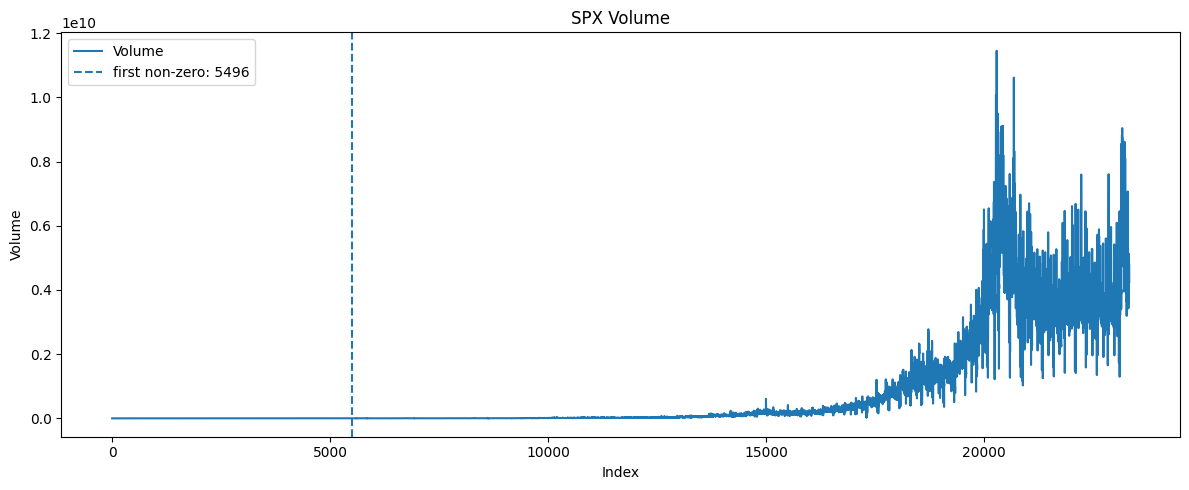

In [4]:
idx = df.index[df["Volume"] != 0]

plt.figure(figsize=(12, 5))
plt.plot(df["Volume"], label="Volume")

if len(idx) > 0:
    first_idx = idx[0]
    plt.axvline(first_idx, linestyle="--", label=f"first non-zero: {first_idx}")
    print("First non-zero index:", first_idx)
    print(df.loc[first_idx])
else:
    print("Volume is all zero.")

plt.xlabel("Index")
plt.ylabel("Volume")
plt.title("SPX Volume")
plt.legend()
plt.tight_layout()
plt.show()

We want to check if there really are no zeros after this date.

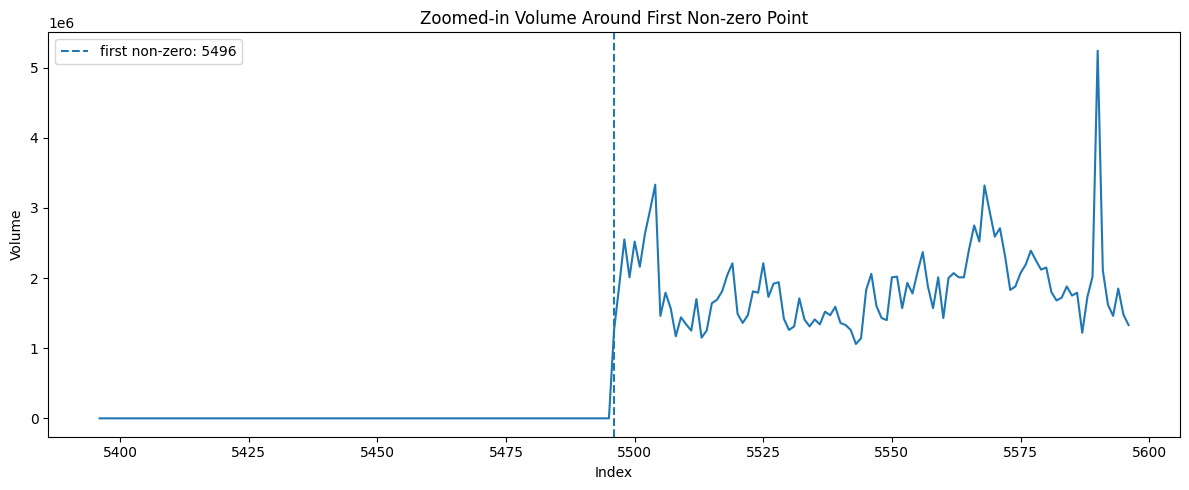

In [5]:
first_idx = df.index[df["Volume"] != 0][0]

start = first_idx - 100
end = first_idx + 100

plt.figure(figsize=(12,5))
plt.plot(df.loc[start:end, "Volume"])
plt.axvline(first_idx, linestyle="--", label=f"first non-zero: {first_idx}")
plt.xlabel("Index")
plt.ylabel("Volume")
plt.title("Zoomed-in Volume Around First Non-zero Point")
plt.legend()
plt.tight_layout()
plt.show()

It seems that the volume data is collected only after 1950-01-03. Let me find some references to prove it.

From S&P 500 Global: The index Launch Date is Mar 04, 1957. All information for an index prior to its Launch Date is hypothetical back-tested, not actual performance, based on the index methodology in effect on the Launch Date.

https://www.spglobal.com/spdji/en/indices/equity/sp-500/#overview

因为前边的是 hypothetical back-tested，我们可以直接从Mar 04, 1957截取 做后面的数据。

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df = df[df["Date"] >= "1957-03-04"].copy()
df = df.reset_index(drop=True)
print(df.shape)
print(df["Date"].min())
print(df.head())

(16031, 7)
1957-03-04 00:00:00
        Date       Open       High        Low      Close  Adj Close   Volume
0 1957-03-04  44.060001  44.060001  44.060001  44.060001  44.060001  1890000
1 1957-03-05  44.220001  44.220001  44.220001  44.220001  44.220001  1860000
2 1957-03-06  44.230000  44.230000  44.230000  44.230000  44.230000  1840000
3 1957-03-07  44.209999  44.209999  44.209999  44.209999  44.209999  1830000
4 1957-03-08  44.070000  44.070000  44.070000  44.070000  44.070000  1630000


In [7]:
print(df.isna().sum())
print("Total missing:", df.isna().sum().sum())
print((df == 0).sum())
print("Total zeros:", (df == 0).sum().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Total missing: 0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Total zeros: 0


No 0s or any missing values now

Moreover, adj close is more precise than Close. so we delete Close and use adj close as close.
（把原Close删了，adj close改名close 减少一列

In [8]:
df = df.drop(columns=["Close"])
df = df.rename(columns={"Adj Close": "Close"})

In [9]:
df.head()
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

save to local

In [10]:
df.to_csv("data_cleaned.csv", index=False)